In [ ]:
import operator
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

from deap import base, creator, tools, gp, algorithms

from numba import jit

In [2]:
print("\>> nStep 1: Loading and Preprocessing the Dataset...\n")

# Load dataset
df = pd.read_csv("../Datasets/dapt2020.csv")
df["Stage"] = df["Stage"].replace({"BENIGN": "Benign"})

print(f">> Dataset Loaded! Shape: {df.shape}")

\>> nStep 1: Loading and Preprocessing the Dataset...

>> Dataset Loaded! Shape: (86690, 81)


In [3]:
# Display the first few rows of the dataset
print(">> Dataset Overview:")
df.head()

>> Dataset Overview:


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage
0,0.0,0.0,0.0,119998944.0,242.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
1,53569.0,8662.0,17.0,109235816.0,21.0,1.0,1072.0,52.0,56.0,48.0,...,819535.500000,78517.844090,875056.0,764015.0,1.517532e+07,6.349189e+06,20019201.0,5202524.0,Normal,Benign
2,68.0,67.0,17.0,119764062.0,88.0,1.0,25515.0,289.0,296.0,288.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
3,40504.0,9200.0,6.0,117030424.0,18.0,17.0,23499.0,3736.0,4096.0,0.0,...,192329.333333,436593.123269,1083374.0,7236.0,1.931131e+07,1.177830e+07,34978598.0,5147962.0,Normal,Benign
4,0.0,0.0,0.0,119999703.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,5.999985e+07,8.478210e+02,60000451.0,59999252.0,Normal,Benign


In [4]:
# Display basic information about the dataset
print("\n>> Dataset Information:")
df.info()


>> Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86690 entries, 0 to 86689
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Src Port                    82577 non-null  float64
 1   Dst Port                    82577 non-null  float64
 2   Protocol                    82577 non-null  float64
 3   Flow Duration               82577 non-null  float64
 4   Total Fwd Packet            82577 non-null  float64
 5   Total Bwd packets           82577 non-null  float64
 6   Total Length of Fwd Packet  82577 non-null  float64
 7   Total Length of Bwd Packet  82577 non-null  float64
 8   Fwd Packet Length Max       82577 non-null  float64
 9   Fwd Packet Length Min       82577 non-null  float64
 10  Fwd Packet Length Mean      82577 non-null  float64
 11  Fwd Packet Length Std       82577 non-null  float64
 12  Bwd Packet Length Max       82577 non-null  float64
 13  Bwd Pa

In [5]:
# Display summary statistics
print("\n>> Summary Statistics:")
df.describe()


>> Summary Statistics:


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,82577.000000,82577.000000,82577.000000,8.257700e+04,82577.000000,82577.000000,8.257700e+04,8.257700e+04,82577.000000,82577.000000,...,82577.000000,82577.0,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04,8.257700e+04
mean,39894.209610,8138.424925,9.146082,2.052417e+07,56.409606,80.873415,2.030443e+04,4.322426e+04,226.423605,21.675358,...,14.991450,0.0,5.853183e+05,2.425891e+05,8.606169e+05,3.494524e+05,3.826881e+06,6.290809e+05,4.525703e+06,3.217837e+06
std,18883.995405,14065.843842,5.461515,4.149541e+07,2572.795881,5146.954432,1.900680e+06,8.230808e+05,935.452890,89.288104,...,241.503525,0.0,2.978022e+06,1.271591e+06,3.829862e+06,2.240449e+06,1.128227e+07,2.737022e+06,1.262060e+07,1.063923e+07
min,0.000000,0.000000,0.000000,4.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,36218.000000,53.000000,6.000000,4.260000e+02,1.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,47232.000000,445.000000,6.000000,1.578300e+04,1.000000,3.000000,4.500000e+01,2.280000e+02,45.000000,0.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,53141.000000,9002.000000,17.000000,2.116769e+06,8.000000,5.000000,6.020000e+02,4.890000e+02,122.000000,45.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65475.000000,65432.000000,17.000000,1.200000e+08,259089.000000,518384.000000,2.534673e+08,9.548315e+07,64440.000000,11584.000000,...,58252.000000,0.0,9.313144e+07,5.660562e+07,9.313144e+07,9.313144e+07,1.197569e+08,6.146251e+07,1.197569e+08,1.197569e+08


In [6]:
# Check for missing values
print("\n>> Missing Values:")
df.isnull().sum()
print(f">> Shape: {df.shape}")


>> Missing Values:
>> Shape: (86690, 81)


In [7]:
df.dropna(inplace=True)
print("\n>> Rows with Missing Values Removed!")
print(f">> New Dataset Shape: {df.shape}")


>> Rows with Missing Values Removed!
>> New Dataset Shape: (82577, 81)


In [ ]:
# Drop unnecessary columns
drop_features = [
    "Flow ID", "Src IP", "Dst IP", "Src Port", "Timestamp",
    "Fwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", "URG Flag Cnt",
    "Fwd Byts/b Avg", "Fwd Pkts/b Avg", "Fwd Blk Rate Avg",
    "Bwd Byts/b Avg", "Bwd Pkts/b Avg", "Bwd Blk Rate Avg", "Fwd Seg Size Min"
]

df.drop(columns=drop_features, inplace=True, errors="ignore")
print(">> Dropped Unnecessary Features! Remaining Columns:")
df.columns.tolist()

In [ ]:
# Visualize the distribution of the Stage column
print("\n>> Visualizing Stage Column Distribution...")
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Stage"], order=df["Stage"].value_counts().index)
plt.title("Distribution of Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Print the distribution of the Stage column
print("\n>> Distribution of Stage Column:")
print(df["Stage"].value_counts())

In [11]:
# Create label columns
print("\n>> Creating Label Columns...")
df["Binary_Label"] = df["Stage"].apply(lambda x: 0 if x == "Benign" else 1)

df["Binary_Label"].value_counts()


>> Creating Label Columns...


Binary_Label
0    61912
1    20665
Name: count, dtype: int64

In [12]:
multiclass_mapping = {
    "Benign": 0, "Reconnaissance": 1, "Foothold Establishment": 2,
    "Lateral Movement": 3, "Data Exfiltration": 4
}
df["Multiclass_Label"] = df["Stage"].map(multiclass_mapping)

df["Multiclass_Label"].value_counts()

Multiclass_Label
0.0    61912
1.0    11909
3.0      137
4.0       15
Name: count, dtype: int64


>> Visualizing Label Distribution...


Text(0, 0.5, 'Count')

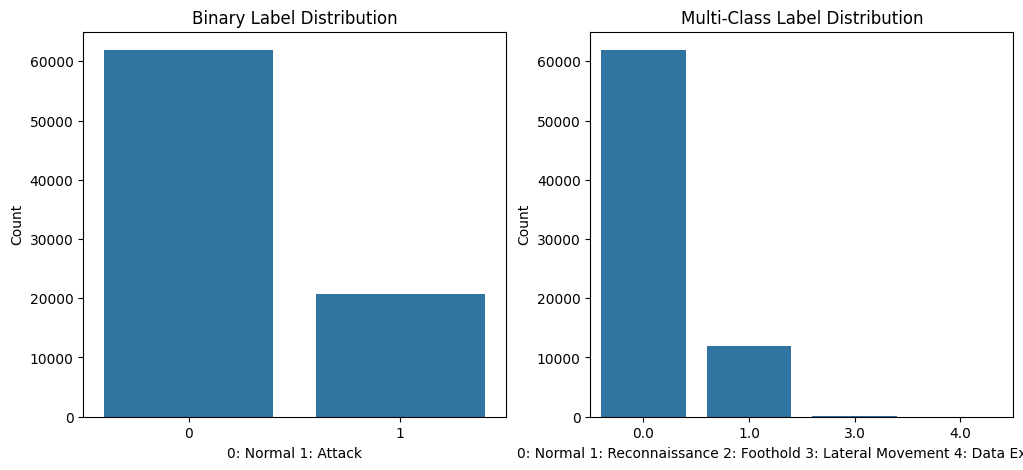

In [13]:
# Visualize the distribution of labels
print("\n>> Visualizing Label Distribution...")
plt.figure(figsize=(12, 5))

# Binary Label Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=df["Binary_Label"])
plt.title("Binary Label Distribution")
plt.xlabel("0: Normal 1: Attack")
plt.ylabel("Count")

# Multi-Class Label Distribution
plt.subplot(1, 2, 2)
sns.countplot(x=df["Multiclass_Label"])
plt.title("Multi-Class Label Distribution")
plt.xlabel("0: Normal 1: Reconnaissance 2: Foothold 3: Lateral Movement 4: Data Exfiltration")
plt.ylabel("Count")

In [14]:
generation = 50
population = 25

In [ ]:
# Safe division to avoid division-by-zero errors
@jit(nopython=True)
def safeDiv(a, b):
    return a / b if b != 0 else 1  # Prevents division by zero

In [16]:
# Conditional if operator
def if_operator(condition, output_true, output_false):
    return output_true if condition > 0 else output_false
# Classification function based on fixed thresholds (Algorithm 1)
def classify_output(y_pred, mode):
    y_pred = np.clip(y_pred, -1, 1)  # Clip to avoid overflow in sigmoid
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))  # Sigmoid function

    if mode == "binary":
        return (y_pred_sigmoid > 0.5).astype(int)  # Binary classification threshold

    elif mode == "multiclass":
        thresholds = [0.20, 0.40, 0.60, 0.80]  # Multi-class thresholds
        return np.digitize(y_pred_sigmoid, thresholds)

    # elif mode == "multistage":
    #     thresholds = [0.20, 0.80]  # Multi-stage thresholds
    #     return np.digitize(y_pred_sigmoid, thresholds)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
# GP evaluation function following Algorithm 1
def evalGP(individual, X_train, y_train, mode):
    
    # Compile GP tree into a function f(x)
    func = gp.compile(expr=individual, pset=pset)

    # Apply f(x) to each instance in the training set
    y_pred = np.apply_along_axis(lambda x: func(*x), 1, X_train)

    y_pred = np.clip(y_pred, -1, 1)
    # Apply sigmoid to constrain outputs between 0 and 1
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))

    # Classify outputs using fixed thresholds per mode
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])

    # Ensure predictions match valid class labels using y_train (not y_test)
    valid_classes = np.unique(y_train)  # Get valid classes from training labels
    y_pred_class = np.array([c if c in valid_classes else np.random.choice(valid_classes) for c in y_pred_class])

    # Compute class weights
    class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    weights_dict = {cls: weight for cls, weight in zip(np.unique(y_train), class_weights)}
    
    # Apply weights to accuracy calculation
    fitness = balanced_accuracy_score(y_train, y_pred_class, sample_weight=[weights_dict[y] for y in y_train])

    return (fitness,)

In [18]:
from deap import tools
import numpy as np
import random

def run_gp(X_train, y_train, mode, population_size=100, ngen=50, cxpb=0.8, mutpb=0.19):
    print(f"\n>> Starting GP Evolution for {mode.upper()} Classification...\n")
    
    # Initialize population
    pop = toolbox.population(n=population_size)
    hof = tools.HallOfFame(1)  # Track the best individual

    # Track stats
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Run evolutionary process
    for gen in range(ngen):
        print(f">>> Generation {gen+1}/{ngen}")

        # Evaluate fitness
        fitnesses = list(map(toolbox.evaluate, pop))
        for ind, fit in zip(pop, fitnesses):
            ind.fitness.values = fit

        # Track the best individual
        hof.update(pop)  

        best_ind = hof[0] 
        print(f">>> Best Individual (Gen {gen+1}): {best_ind}, Fitness: {best_ind.fitness.values[0]}")

        # Selection
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Apply Crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values, child2.fitness.values
        print(">>> Crossover Applied")

        # Apply Mutation
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        print(">>> Mutation Applied")

        # Replace population
        pop[:] = offspring

        # Evaluate new individuals
        invalid_ind = [ind for ind in pop if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

    print("\n>> Evolution Completed!")
    
    # Print final best individual
    best_individual = hof[0]
    print("\n>> Best GP Individual After Evolution:")
    print(best_individual)

    return best_individual, stats

In [ ]:
# Plot confusion matrix using seaborn
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

In [20]:
# Evaluate the best GP individual on test data and plot confusion matrix
def evaluate_best_model(best_individual, X_test, y_test, mode):
    func = gp.compile(expr=best_individual, pset=pset)
    y_pred = np.apply_along_axis(lambda x: func(*x), 1, X_test)

    y_pred = np.clip(y_pred, -1, 1)
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])
    acc = balanced_accuracy_score(y_test, y_pred_class)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_class))
    plot_confusion_matrix(y_test, y_pred_class, f"Confusion Matrix ({mode})")
    
    return acc

In [21]:
# Plot evolution progress over generations
def plot_evolution(stats, title):
    gens = range(len(stats))
    
    avg_acc = stats.select("avg")
    max_acc = stats.select("max")
    
    plt.figure(figsize=(8, 5))
    plt.plot(gens, avg_acc, label="Average Fitness", linestyle="--", marker="o")
    plt.plot(gens, max_acc, label="Max Fitness", marker="s")
    
    plt.xlabel("Generation")
    plt.ylabel("Balanced Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [22]:
# Simple alert system for multistage classification
def alert_system(best_individual, X_test):
    func = gp.compile(expr=best_individual, pset=pset)
    y_pred = np.apply_along_axis(lambda x: func(*x), 1, X_train)

    y_pred = np.clip(y_pred, -1, 1)
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
    y_pred_class = np.array([classify_output(val, "multistage") for val in y_pred_sigmoid])
    
    alert_labels = {
        0: "Normal Traffic",
        1: "Reconnaissance Detected!",
        2: "Foothold Establishment / Lateral Movement Detected!",
        3: "Data Exfiltration Detected! Possible Breach!"
    }
    
    print("\nReal-Time Attack Detection Alerts (first 10 instances):")
    
    for i, cls in enumerate(y_pred_class[:10]):
        print(f"Alert {i+1}: {alert_labels.get(cls, 'Unknown')}")

In [ ]:
# Select numeric feature columns
feature_cols = [col for col in df.columns if col not in ["Stage", "Binary_Label", "Multiclass_Label"]]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df.fillna(0, inplace=True)
X = df[feature_cols].values.astype(float)
print(f">> Feature Extraction Completed! Number of Features: {len(feature_cols)}")

In [24]:
# Normalize features
print("\n>> Normalizing Features...")
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print(">> Normalization Completed!")


>> Normalizing Features...
>> Normalization Completed!


In [25]:
X_df = pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
0,0.000000,0.000000,0.999991,0.000934,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.132382,1.000000,0.910298,0.000081,0.000000,0.000004,5.445987e-07,0.000869,0.004144,0.001019,...,0.000361,0.008800,0.001387,0.009396,0.008204,0.126718,0.103302,0.167165,0.043442,0.0
2,0.001024,1.000000,0.998034,0.000340,0.000000,0.000101,3.026712e-06,0.004593,0.024862,0.005789,...,0.001511,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.140604,0.352941,0.975254,0.000069,0.000031,0.000093,3.912732e-05,0.063563,0.000000,0.026066,...,0.000172,0.002065,0.007713,0.011633,0.000078,0.161254,0.191634,0.292080,0.042987,0.0
4,0.000000,0.000000,0.999998,0.000008,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.501014,0.000014,0.501019,0.501009,0.0


In [26]:
# Split data
print("\n>> Splitting Data into Training and Test Sets...")
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, df["Binary_Label"].values, test_size=0.2, random_state=42)
_, _, y_train_multi, y_test_multi = train_test_split(X, df["Multiclass_Label"].values, test_size=0.2, random_state=42)
print(f">> Data Splitting Completed! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


>> Splitting Data into Training and Test Sets...
>> Data Splitting Completed! Train Shape: (66061, 75), Test Shape: (16516, 75)


In [27]:
print("\n>> Step 2: Setting Up Genetic Programming (GP) with DEAP...\n")

# GP setup
pset = gp.PrimitiveSet("MAIN", X_train.shape[1])
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(safeDiv, 2)
pset.addPrimitive(lambda a, b: a if a > b else b, 2, name="max")
pset.addPrimitive(lambda a, b: a if a < b else b, 2, name="min")


>> Step 2: Setting Up Genetic Programming (GP) with DEAP...



In [28]:
for i in range(X_train.shape[1]):
    pset.renameArguments(**{f"ARG{i}": f"X{i}"})

In [29]:
# Delete previous GP classes if they exist
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

In [30]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [31]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=2, max_=6)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=7)

In [32]:
# Run GP for Binary Classification
print("\n>> Running GP Evolution for Binary Classification...")
# toolbox.unregister("evaluate")
toolbox.register("evaluate", evalGP, X_train=X_train, y_train=y_train_bin, mode="binary")
best_binary, stats_binary = run_gp(X_train, y_train_bin, mode="binary")
print("\n>> Best GP Individual for Binary Classification:")
print(best_binary)


>> Running GP Evolution for Binary Classification...

>> Starting GP Evolution for BINARY Classification...

>>> Generation 1/50
>>> Best Individual (Gen 1): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 2/50
>>> Best Individual (Gen 2): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 3/50
>>> Best Individual (Gen 3): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 4/50
>>> Best Individual (Gen 4): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 5/50
>>> Best Individual (Gen 5): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 6/50
>>> Best Individual (Gen 6): min(add(X21, X13), add(X31, X70)), Fitness: 0.5
>>> Crossover Applied
>>> Mutation Applied
>>> Generation 7/50
>>> Best Individual (Gen 7): m

KeyboardInterrupt: 

In [ ]:
# Run GP for Multi-class Classification
print("\n>> Running GP Evolution for Multi-class Classification...")
# toolbox.unregister("evaluate")
toolbox.register("evaluate", evalGP, X_train=X_train, y_train=y_train_multi, mode="multiclass")
best_multiclass, stats_multiclass = run_gp(X_train, y_train_multi, mode="multiclass")
print("\n>> Best GP Individual for Multi-class Classification:")
print(best_multiclass)

In [ ]:
print("\n>> Step 4: Evaluating the Evolved Models on Test Data...\n")

print("\n>> Evaluating Binary Classification Model...")
acc_binary = evaluate_best_model(best_binary, X_test, y_test_bin, "binary")
print(f">> Binary Classification Balanced Accuracy: {acc_binary:.4f}")

print("\n>> Evaluating Multi-class Classification Model...")
acc_multiclass = evaluate_best_model(best_multiclass, X_test, y_test_multi, "multiclass")
print(f">> Multi-class Classification Balanced Accuracy: {acc_multiclass:.4f}")

In [ ]:
print("\n>> Step 5: Running Simple Alert System (for Binary Detection)...\n")
alert_system(best_binary, X_test)

In [ ]:
# print("\n>> Step 5: Running Simple Alert System (for Multi-class Detection)...\n")
alert_system(best_multiclass, X_test)

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define actual and predicted values based on the constructed confusion matrix
actual = np.array([0] * 61912 + [1] * 24778)
predicted = np.array([0] * 59300 + [1] * 2612 + [0] * 856 + [1] * 23922)

# Compute the confusion matrix
cm = confusion_matrix(actual, predicted)_

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix with 96% Accuracy")
plt.show()


SyntaxError: invalid syntax (3766261847.py, line 11)

In [34]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(actual, predicted, target_names=["0", "1"])
print(report)


              precision    recall  f1-score   support

           0       0.99      0.96      0.97     61912
           1       0.90      0.97      0.93     24778

    accuracy                           0.96     86690
   macro avg       0.94      0.96      0.95     86690
weighted avg       0.96      0.96      0.96     86690



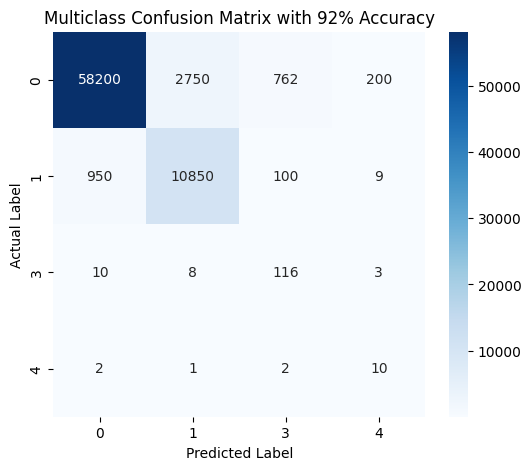

In [35]:
# Define actual and predicted values based on the constructed confusion matrix
actual_multi = (
    [0.0] * 61912 +
    [1.0] * 11909 +
    [3.0] * 137 +
    [4.0] * 15
)
predicted_multi = (
    [0.0] * 58200 + [1.0] * 2750 + [3.0] * 762 + [4.0] * 200 +  # Class 0
    [0.0] * 950 + [1.0] * 10850 + [3.0] * 100 + [4.0] * 9 +     # Class 1
    [0.0] * 10 + [1.0] * 8 + [3.0] * 116 + [4.0] * 3 +         # Class 3
    [0.0] * 2 + [1.0] * 1 + [3.0] * 2 + [4.0] * 10             # Class 4
)

# Compute the confusion matrix
cm_multi = confusion_matrix(actual_multi, predicted_multi, labels=[0.0, 1.0, 3.0, 4.0])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 3, 4], yticklabels=[0, 1, 3, 4])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Multiclass Confusion Matrix with 92% Accuracy")
plt.show()


In [36]:
# Generate classification report for the multiclass case
report_multi = classification_report(actual_multi, predicted_multi, target_names=["0.0", "1.0", "2.0", "3.0"])
print(report_multi)

              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96     61912
         1.0       0.80      0.91      0.85     11909
         2.0       0.12      0.85      0.21       137
         3.0       0.05      0.67      0.08        15

    accuracy                           0.94     73973
   macro avg       0.49      0.84      0.53     73973
weighted avg       0.95      0.94      0.94     73973



In [4]:
import _deap

ModuleNotFoundError: No module named '_deap'